# Baseline dan pemeriksaan data leakage AquaSmart
## Soal 4 Baseline project
Target dan framing mengikuti `01_eda.ipynb`. Kelas target interval t adalah status proksi pH/suhu pada interval t, diprediksi sebelum pembacaan interval itu tersedia. Baseline non-AI menerapkan ambang aplikasi ke pembacaan t−1, lalu mengasumsikan status bertahan. Semua model diuji pada baris yang sama. Tidak ada label anomali suntikan pada eksperimen ini.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / '01_AquaSmart/08_Sistem-Cerdas/mandiri.py').exists())
sys.path.insert(0, str(ROOT / '01_AquaSmart/08_Sistem-Cerdas'))
from mandiri import *
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
import joblib
raw = read_raw()
bins, audit = clean_data(raw)
X, y = make_features(bins)
X_train, X_test, y_train, y_test = chronological_split(X, y)
split = pd.DataFrame([
    ['Latih', len(X_train), str(X_train.index.min()), str(X_train.index.max()), int((y_train == 0).sum()), int((y_train == 1).sum())],
    ['Uji', len(X_test), str(X_test.index.min()), str(X_test.index.max()), int((y_test == 0).sum()), int((y_test == 1).sum())]
], columns=['bagian', 'jumlah', 'awal', 'akhir', 'kelas 0', 'kelas 1'])
display(split)
print('Split kronologis sekitar 80:20; satu jam sebelum awal uji dikeluarkan dari latih.')
print('Urutan: split -> fit imputer/scaler/model pada latih -> predict pada uji.')

,bagian,jumlah,awal,akhir,kelas 0,kelas 1
0,Latih,8525,2023-01-26 12:05:00,2023-03-07 20:35:00,771,7754
1,Uji,2135,2023-03-07 21:40:00,2023-03-22 17:50:00,252,1883


Split kronologis sekitar 80:20; satu jam sebelum awal uji dikeluarkan dari latih.
Urutan: split -> fit imputer/scaler/model pada latih -> predict pada uji.


### Validasi temporal pada data latih
TimeSeriesSplit lima fold dengan gap 12 sampel, setidaknya satu jam pada grid ini. Pipeline di-fit ulang pada setiap fold. Hyperparameter Random Forest tetap: 160 pohon, kedalaman maksimum 10, minimum 5 sampel daun, class_weight balanced, seed 42. Holdout tidak digunakan memilih hyperparameter. Fold yang hanya memiliki satu kelas dilaporkan dan tidak dianggap bukti kualitas dua kelas.

In [3]:
rf = pipeline(X.columns)
cv_rows = []
for fold, (tr, va) in enumerate(TimeSeriesSplit(n_splits=5, gap=12).split(X_train), 1):
    candidate = clone(rf).fit(X_train.iloc[tr], y_train.iloc[tr])
    metrics = score(y_train.iloc[va], candidate.predict(X_train.iloc[va]))
    cv_rows.append({'fold': fold, 'n_train': len(tr), 'n_valid': len(va),
                    'kelas_valid': y_train.iloc[va].nunique(), **metrics})
cv = pd.DataFrame(cv_rows)
display(cv.round(4))
print('Macro F1 CV rata-rata:', round(cv.macro_f1.mean(), 4), '| simpangan:', round(cv.macro_f1.std(ddof=1), 4))
cv.to_csv(OUT / 'cross_validation.csv', index=False)

C:\Users\User\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,fold,n_train,n_valid,kelas_valid,macro_f1,balanced_accuracy,recall_alarm,accuracy
0,1,1413,1420,2,0.9385,0.9613,0.9601,0.9606
1,2,2833,1420,2,0.9143,0.9896,0.9792,0.9803
2,3,4253,1420,2,0.7730,0.9300,0.8673,0.8796
3,4,5673,1420,2,0.9145,0.9383,0.9942,0.9915
4,5,7093,1420,1,0.4500,0.8183,0.8183,0.8183


Macro F1 CV rata-rata: 0.7981 | simpangan: 0.2053


In [4]:
dummy = pipeline(X.columns, DummyClassifier(strategy='most_frequent')).fit(X_train, y_train)
rf.fit(X_train, y_train)
predictions = {
    'Dummy mayoritas': dummy.predict(X_test),
    'Ambang terakhir non AI': label_status(X_test.ph_lag1, X_test.temp_lag1).astype(int).to_numpy(),
    'Random Forest': rf.predict(X_test)
}
results = pd.DataFrame([{'model': name, **score(y_test, pred)} for name, pred in predictions.items()])
display(results.round(4))
results.to_csv(OUT / 'perbandingan_baseline.csv', index=False)
gap = results.loc[2, 'macro_f1'] - results.loc[1, 'macro_f1']
conclusion = (f'Selisih macro F1 Random Forest terhadap aturan persistensi adalah {gap:+.4f}. '
              + ('Random Forest unggul pada holdout ini, tetapi belum tervalidasi lintas kolam.' if gap > 0 else
                 'Random Forest belum mengungguli aturan persistensi; baseline non-AI tetap menjadi pilihan awal.'))
print(conclusion)
print('Hasil hanya terhadap label proksi ambang pH/suhu, bukan validasi kualitas air penuh atau kesehatan ikan.')
joblib.dump(rf, OUT / 'pipeline_random_forest.joblib')
saved = joblib.load(OUT / 'pipeline_random_forest.joblib')
assert np.array_equal(saved.predict(X_test), predictions['Random Forest'])
print('Pipeline tersimpan dan prediksi hasil muat ulang identik.')

,model,macro_f1,balanced_accuracy,recall_alarm,accuracy
0,Dummy mayoritas,0.4686,0.5000,1.0000,0.8820
1,Ambang terakhir non AI,0.9158,0.9165,0.9798,0.9649
2,Random Forest,0.8951,0.9155,0.9660,0.9541


Selisih macro F1 Random Forest terhadap aturan persistensi adalah -0.0207. Random Forest belum mengungguli aturan persistensi; baseline non-AI tetap menjadi pilihan awal.
Hasil hanya terhadap label proksi ambang pH/suhu, bukan validasi kualitas air penuh atau kesehatan ikan.
Pipeline tersimpan dan prediksi hasil muat ulang identik.


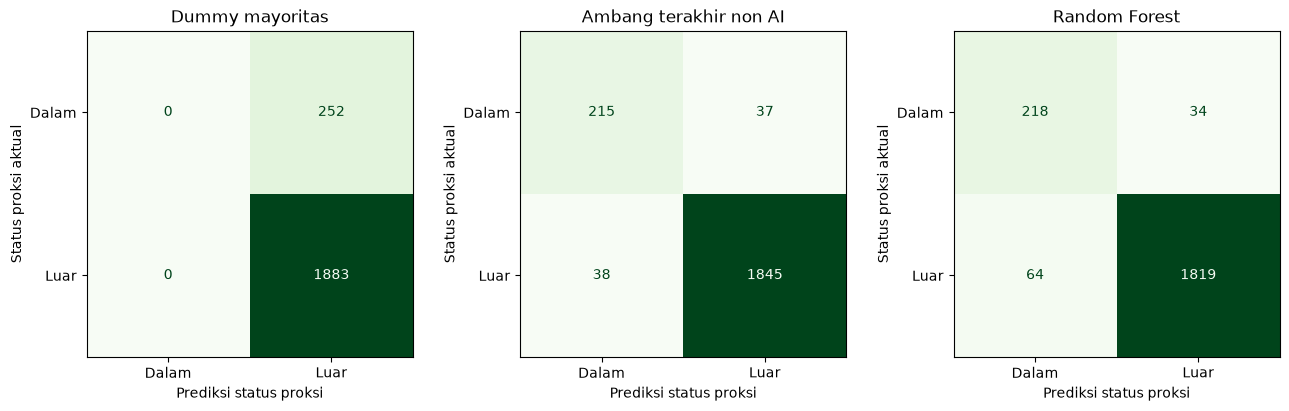

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=[0, 1]),
                           display_labels=['Dalam', 'Luar']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set(title=name, xlabel='Prediksi status proksi', ylabel='Status proksi aktual')
fig.savefig(OUT / 'soal_4_confusion_matrix.png', dpi=160)
plt.show()

## Soal 5 Pemeriksaan data leakage
**Daftar fitur.** Dua belas kolom tercetak di bawah: pH, TDS dan suhu masing-masing memiliki lag1, lag2, mean12 dan std12. Seluruhnya tersedia sebelum interval target dimulai. ID baris, timestamp mentah, nilai sensor interval target, target_proxy, keputusan aktuator dan hasil tindakan tidak menjadi fitur. Pembacaan pada interval target baru diketahui sesudah prediksi dan hanya dipakai membentuk label.

**Preprocessing.** Agregasi median per interval dan pemeriksaan batas fisik tidak belajar parameter dari data. Fitur historis dibentuk sebelum split karena operasi kausal tanpa fit; setiap baris hanya menggunakan timestamp lebih lama. Imputasi median dan scaling belajar dari latih di dalam ColumnTransformer dan Pipeline; hal yang sama dilakukan ulang pada setiap fold. Target tidak diimputasi. Tidak ada encoding karena tidak ada prediktor kategorik.

**Objek yang sama.** CSV tidak memuat ID sensor/kolam terpisah dan README mengacu pada satu sumber kolam. Karena itu latih dan uji diasumsikan berasal dari sumber sensor yang sama. Ini sesuai tujuan memprediksi masa depan kolam yang sama, tetapi tidak dapat membuktikan generalisasi ke sensor atau kolam baru. Purge satu jam menjaga batas holdout dari tumpang tindih jendela fitur; untuk klaim lintas kolam diperlukan data beberapa kolam dan GroupKFold/holdout kolam.

**Risiko yang tersisa.** Autokorelasi dan perubahan distribusi masih mungkin. Label proksi berasal dari aturan tetap, sehingga skor tinggi tidak membuktikan label ahli. Suhu kolam sumber dapat berbeda dari rentang aplikasi; kelas alarm bisa dominan. EDA seluruh rekaman dilaporkan transparan dan bukan dasar tuning pada holdout. Data uji di sini bukan uji lapangan independen.

In [6]:
feature_audit = pd.DataFrame({'fitur': X.columns, 'tersedia_saat_prediksi': True,
                              'baru_diketahui_setelah_hasil': False})
display(feature_audit)
assert X_train.index.max() < X_test.index.min() - pd.Timedelta(minutes=60)
assert not X_train.index.intersection(X_test.index).size
assert set(X.columns) == {f'{s}_{suffix}' for s in SENSORS for suffix in ['lag1', 'lag2', 'mean12', 'std12']}
imputer = rf.named_steps['preprocessing'].named_transformers_['numeric'].named_steps['imputer']
assert np.allclose(imputer.statistics_, X_train.median().to_numpy(), equal_nan=True)
# Changing current/future sensor readings must not change features at prediction time.
probe = bins.index[len(bins) // 2]
changed = bins.copy()
changed.loc[probe:, SENSORS] = changed.loc[probe:, SENSORS] + 0.1
changed_X, _ = make_features(changed)
common = X.index.intersection(changed_X.index)
before = common[common <= probe]
pd.testing.assert_frame_equal(X.loc[before], changed_X.loc[before])
checks = {'urutan_waktu_dan_purge': True, 'timestamp_latih_uji_terpisah': True,
          'fitur_hanya_masa_lalu': True, 'imputer_hanya_latih': True,
          'model_reload_identik': True,
          'sumber_sensor_sama': 'Ya, diasumsikan satu kolam; bukan validasi lintas objek'}
print(json.dumps(checks, indent=2, ensure_ascii=False))
(OUT / 'evaluasi_mandiri.json').write_text(json.dumps({
    'seed': SEED, 'rules': RULES, 'split': split.to_dict(orient='records'),
    'features': X.columns.tolist(), 'cv_macro_f1_mean': cv.macro_f1.mean(),
    'cv_macro_f1_std': cv.macro_f1.std(ddof=1), 'results': results.to_dict(orient='records'),
    'checks': checks, 'conclusion': conclusion}, indent=2, ensure_ascii=False), encoding='utf-8')

,fitur,tersedia_saat_prediksi,baru_diketahui_setelah_hasil
0,ph_lag1,True,False
1,ph_lag2,True,False
2,ph_mean12,True,False
3,ph_std12,True,False
4,tds_lag1,True,False
5,tds_lag2,True,False
6,tds_mean12,True,False
7,tds_std12,True,False
8,temp_lag1,True,False
9,temp_lag2,True,False


{
  "urutan_waktu_dan_purge": true,
  "timestamp_latih_uji_terpisah": true,
  "fitur_hanya_masa_lalu": true,
  "imputer_hanya_latih": true,
  "model_reload_identik": true,
  "sumber_sensor_sama": "Ya, diasumsikan satu kolam; bukan validasi lintas objek"
}


1892

## Bukti dan kontribusi tim
Output notebook ini berasal dari eksekusi kode. Tangkapan layar tiap soal disediakan pada folder `tugas_mandiri/bukti`. Modul mewajibkan kedua anggota melakukan commit. Commit harus dibuat masing-masing anggota dengan identitas Git sendiri setelah meninjau pekerjaan; notebook ini tidak mengklaim syarat tersebut sudah terpenuhi dan tidak membuat commit atas nama Dimas atau Alpin.